shape: (569, 30)
classes: [np.str_('malignant'), np.str_('benign')]

report:
               precision    recall  f1-score   support

   malignant       0.93      0.89      0.91        45
      benign       0.95      0.97      0.96        98

    accuracy                           0.94       143
   macro avg       0.94      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143

accuracy: 0.9441


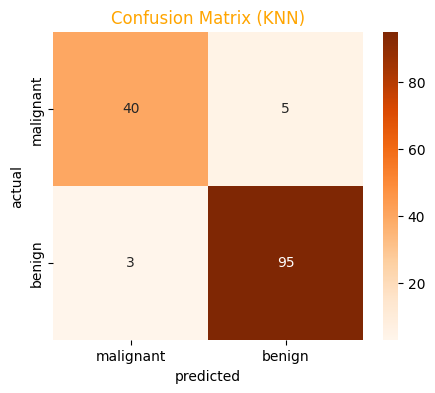

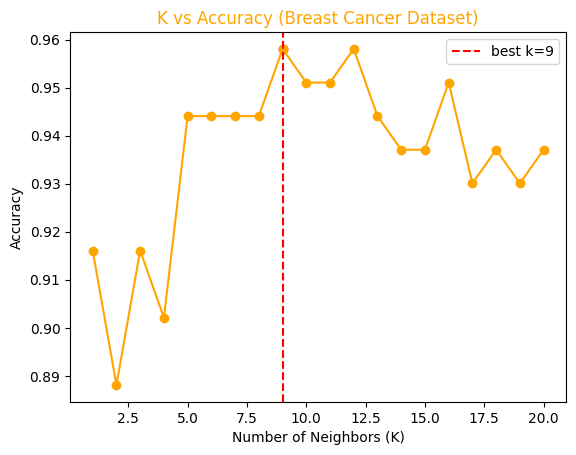

In [1]:
# KNN Implementation

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load Dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)

print("shape:", X.shape)
print("classes:", list(cancer.target_names))

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)

# Train KNN Model
k = 7
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Predict & Evaluate
y_pred = knn.predict(X_test)

print("\nreport:\n", classification_report(y_test, y_pred, target_names=cancer.target_names))
print("accuracy:", round(accuracy_score(y_test, y_pred), 4))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sn.heatmap(cm, annot=True, fmt='d',
           cmap="Oranges", xticklabels=cancer.target_names,
           yticklabels=cancer.target_names)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Confusion Matrix (KNN)", color="orange")
plt.show()

# Accuracy vs K Plot
k_values = range(1, 21)
scores = []
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    scores.append(knn_temp.score(X_test, y_test))

best_k = k_values[scores.index(max(scores))]
best_acc = max(scores)

plt.plot(k_values, scores, marker='o', color="orange")
plt.axvline(best_k, linestyle="--", color="red", label=f"best k={best_k}")
plt.scatter(best_k, best_acc, color="red")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy (Breast Cancer Dataset)", color="orange")
plt.legend()
plt.show()
